# ZINB likelihood

Prepare simulated dataset that is zero inflated negative binomial distributed. Because it is what I work with, it is supposed to resemble ABCD at baseline.
Apply ZINB likelihood to model the data using the PCNtoolkit.


## Generate simulated data

In [39]:
import numpy as np
import pandas as pd
import pymc as pm

rng = np.random.default_rng(42)

n = 2000 # Small sample size to run notebook fast

# ABCD-like baseline age in months
age_months = rng.integers(108, 133, size=n)
sex = np.where(rng.binomial(1, 0.52, size=n) == 1, "F", "M")
site = np.array([f"site{i}" for i in rng.integers(0, 21, size=n)])

age_z = (age_months - age_months.mean()) / age_months.std()
site_id = np.array([int(s[4:]) for s in site])
site_z = (site_id - site_id.mean()) / site_id.std()

# NB mean: linear in age, sex and site on the log scale
eta_mu = 1.2 + 0.35 * age_z + 0.25 * (sex == "F") + 0.08 * site_z
mu = np.clip(np.exp(eta_mu), 0.1, 16.0)

# NB zero-inflation probability (psi) on the logit scale
eta_psi = 1.0 - 0.2 * age_z - 0.1 * (sex == "F") - 0.10 * (site_id == 0)
psi = np.clip(1 / (1 + np.exp(-eta_psi)), 0.70, 0.98) # structural zeros are (1 - psi), so here roughly 2-30% of the sample.

# NB shape parameter (alpha)
alpha = 2.5

# Draw straight from PyMC so the data matches the fitted likelihood exactly.
y = pm.draw(
    pm.ZeroInflatedNegativeBinomial.dist(psi=psi, mu=mu, alpha=alpha),
    random_seed=42,
).astype(int)

df = pd.DataFrame({
    "age": age_months,
    "sex": sex,
    "site": site,
    "age_z": age_z,
    "mu": mu,
    "psi": psi,          # P(NB draw), PyMC convention
    "alpha": alpha,      # the NB shape
    "y": y,
})

df.to_csv("zinb_abcd_like_simulated_data.csv", index=False)

summary = pd.Series({
    "n": n,
    "age_mean": age_months.mean(),
    "sex_male_prop": (sex == "M").mean(),
    "mean_mu": mu.mean(),
    "mean_psi": psi.mean(),
    # the fraction who were never in the running for a non-zero count (eg healthy subjects)
    "structural_zero_rate": (1 - psi).mean(),
    # the fraction of people who scored 0 (eg the healthy ones above, PLUS patients 
    # who happened to score 0 this time)
    "zero_rate": (y == 0).mean(),
    "mean_y": y.mean(),
    "expected_mean_psi_mu": (psi * mu).mean(),
    "var_y": y.var(),
    "max_y": y.max(),
})
summary.to_csv("zinb_abcd_like_summary.csv")
summary

n                       2000.000000
age_mean                 120.004500
sex_male_prop              0.475500
mean_mu                    4.073324
mean_psi                   0.728246
structural_zero_rate       0.271754
zero_rate                  0.357500
mean_y                     2.938000
expected_mean_psi_mu       2.927550
var_y                     14.333156
max_y                     41.000000
dtype: float64

## Plot simulated data

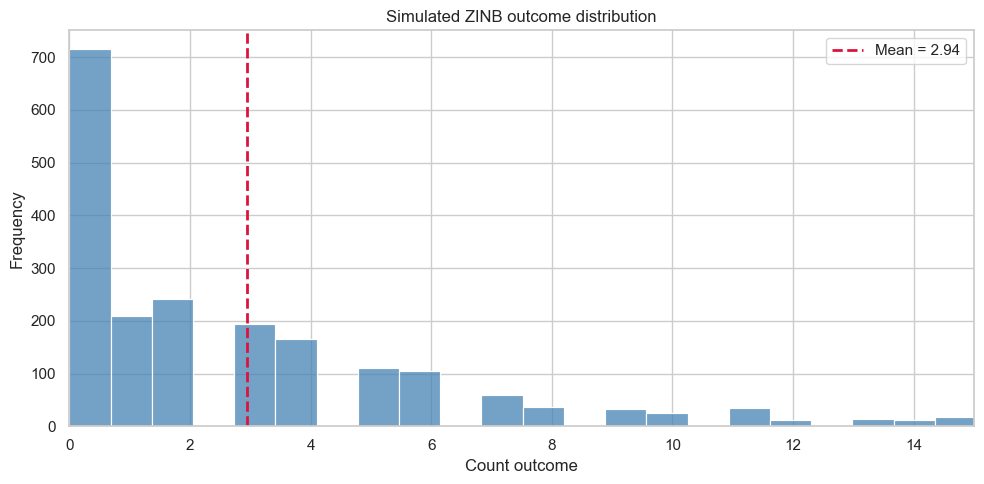

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["y"], bins=60, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Simulated ZINB outcome distribution")
ax.set_xlabel("Count outcome")
ax.set_ylabel("Frequency")
ax.set_xlim(0, np.quantile(df["y"], 0.99))
ax.axvline(df["y"].mean(), color="crimson", linestyle="--", linewidth=2, label=f"Mean = {df['y'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

## Set up PCNtoolkit

In [41]:
import warnings
import logging


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    NormalLikelihood,
    ZeroInflatedNegativeBinomialLikelihood,
    make_prior,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)

import numpy as np
import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(False)

## Build and visualise NormData

      age sex    site     age_z        mu       psi  alpha  y
0     110   F  site13 -1.382274  2.747225  0.764310    2.5  0
1     127   F  site17  0.966535  6.591107  0.700000    2.5  4
2     124   F  site13  0.552039  5.406494  0.700000    2.5  0
3     118   F  site12 -0.276952  3.991600  0.722198    2.5  2
4     118   M   site9 -0.276952  2.987410  0.741809    2.5  4
...   ...  ..     ...       ...       ...       ...    ... ..
1995  108   F   site9 -1.658604  2.365120  0.774120    2.5  1
1996  121   M  site15  0.137543  3.739870  0.725616    2.5  0
1997  132   F   site7  1.657361  7.351415  0.700000    2.5  0
1998  115   M   site2 -0.691448  2.354906  0.757365    2.5  5
1999  115   F   site3 -0.691448  3.064127  0.738520    2.5  0

[2000 rows x 8 columns]
<xarray.DataArray 'batch_effects' (observations: 1999, batch_effect_dims: 2)> Size: 96kB
array([['F', 'site13'],
       ['F', 'site17'],
       ['F', 'site13'],
       ...,
       ['F', 'site7'],
       ['M', 'site2'],
       ['F',

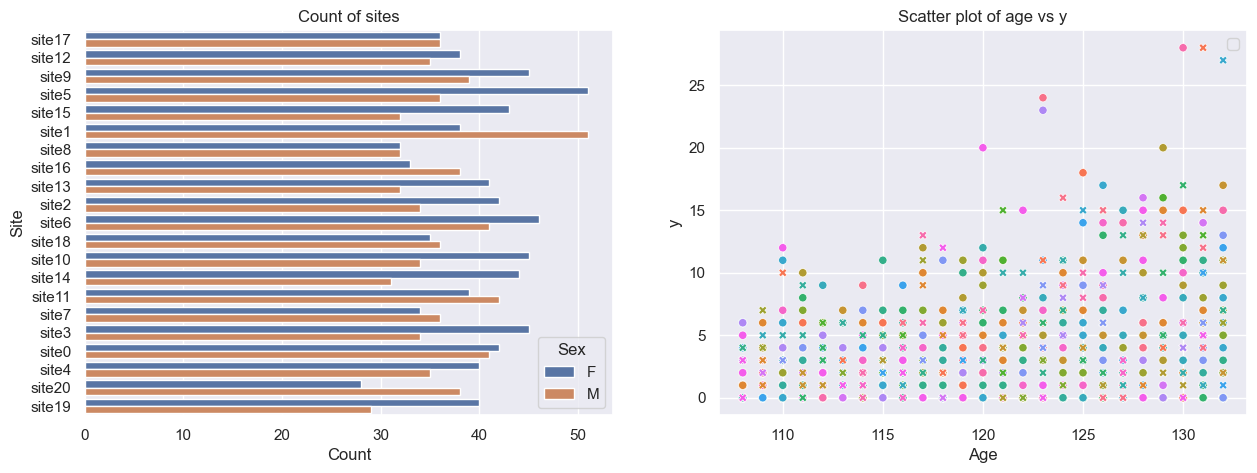

In [42]:
from sklearn.model_selection import train_test_split
from pcntoolkit import NormData

covariate_cols = ["age"]
batch_effects = ["sex", "site"]
response_variables = ["y"]

# Make sure categories / numeric types are sensible
df = df.copy()
df["age"] = df["age"].astype(int)
df["sex"] = df["sex"].astype(str)
df["site"] = df["site"].astype(str)
df["y"] = df["y"].astype(int)

print(df)

# Build NormData
norm_data = NormData.from_dataframe(
    name="ZINB_CBCL_sim",
    dataframe=df,
    covariates=covariate_cols,
    batch_effects=batch_effects,
    response_vars=response_variables,
    remove_outliers=True,
    z_threshold=10,
)

# Split into train and test
train, test = norm_data.train_test_split()

# Visualize the train data
features_to_model = response_variables
feature_to_plot = features_to_model[0]
df = train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, y=("batch_effects", "site"), hue=("batch_effects", "sex"), ax=ax[0], orient="h")
ax[0].legend(title="Sex")
ax[0].set_title("Count of sites")
ax[0].set_xlabel("Count")
ax[0].set_ylabel("Site")


sns.scatterplot(
    data=df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "site"),
    style=("batch_effects", "sex"),
    ax=ax[1],
)
ax[1].legend([], [])
ax[1].set_title(f"Scatter plot of age vs {feature_to_plot}")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

print(norm_data.batch_effects)


## HBR with ZINB likelihood


In [43]:
# Linear variant: no B splines. 
# This simulation is LINEAR in age (eta_mu = 1.2 + 0.35*age_z + ...) so there is no curvature for a spline to find.

mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 5.0)),
    intercept=make_prior(
        random=True, # random effects on the intercept for site and sex
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Gamma", dist_params=(1.0, 1.0)),
    ),
    mapping="softplus",          # mu must be positive
)

alpha = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    mapping="softplus",          # alpha must be positive
    mapping_params=(0.0, 2.0),
)

psi = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0, 1)),
    intercept=make_prior(dist_name="Normal", dist_params=(0, 1)),
    mapping="sigmoid",           # psi is a probability, must be in (0, 1)
)

likelihood = ZeroInflatedNegativeBinomialLikelihood(mu, alpha, psi)

template_hbr = HBR(
    name="template", 
    cores=4, 
    progressbar=True,
    draws=1500, 
    tune=500, 
    chains=4,
    nuts_sampler="nutpie", 
    likelihood=likelihood,
)


In [44]:
model = NormativeModel(
    template_regression_model=template_hbr,
    savemodel=False,
    evaluate_model=False,
    saveresults=False,
    saveplots=False,
    # inscaler scales X (age), not Y. Age is a continuous covariate, so standardizing it is harmless 
    inscaler="standardize",
    # outscaler scales Y. We must not apply the scaling here as 
    # ZINB models counts, so Y must be non-negative and integer.
    outscaler="none",
)

model.fit_predict(train, test)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,53,0.38,15
,2000,14,0.31,15
,2000,81,0.37,15
,2000,13,0.45,7


<xarray.NormData> Size: 61kB
Dimensions:            (observations: 400, response_vars: 1, covariates: 1,
                        batch_effect_dims: 2, centile: 5)
Coordinates:
  * observations       (observations) int64 3kB 1176 1275 1689 ... 745 690 95
  * response_vars      (response_vars) <U1 4B 'y'
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
Data variables:
    subject_ids        (observations) int64 3kB 1176 1275 1689 ... 745 690 95
    Y                  (observations, response_vars) float64 3kB 1.0 5.0 ... 3.0
    X                  (observations, covariates) float64 3kB 115.0 ... 115.0
    batch_effects      (observations, batch_effect_dims) <U6 19kB 'F' ... 'si...
    Z                  (observations, response_vars) float64 3kB -0.226 ... 0...
    centiles           (centile, observations, response_vars) float64 16kB 0....
    baseline_logp      (observations, response_vars) float64 3kB -2.404 ... -...
    logp               (observations, response_vars) float64 3kB -2.088 ... -...
    Yhat               (observations, response_vars) float64 3kB 2.538 ... 2.589
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           ZINB_CBCL_sim_test
    unique_batch_effects:           {np.str_('sex'): ['F', 'M'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 108.0, 'max': 13...
    batch_effect_covariate_ranges:  {np.str_('sex'): {'F': {np.str_('age'): {...

## Plot centiles

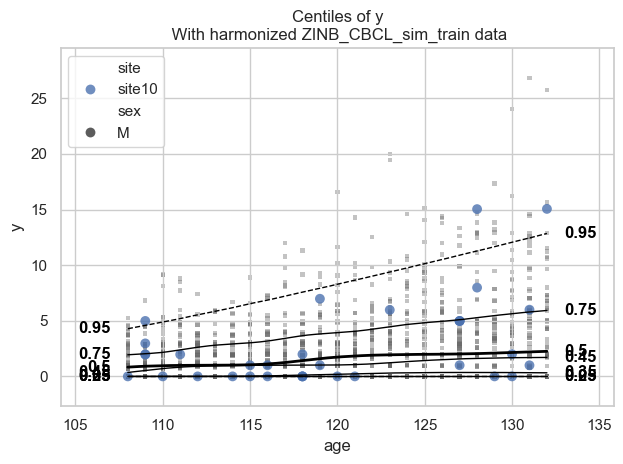

[<Figure size 640x480 with 1 Axes>]

In [45]:
plot_centiles_advanced(
    model,
    centiles=[0.05, 0.25, 0.35, 0.45, 0.5, 0.75, 0.95],  # Plot these centiles, the default is [0.05, 0.25, 0.5, 0.75, 0.95]
    scatter_data=train,  # Scatter this data along with the centiles
    batch_effects={"site": ["site10"], "sex": ["M"]},  # Highlight these groups
    show_other_data=True,  # scatter data not in those groups as smaller black circles
    harmonize_data=True,  # harmonize the scatterdata, this means that we 'remove' the batch effects from the data, by simulating what the data would have looked like if all data was from the same batch.
)